<a href="https://colab.research.google.com/github/anuragN2107/Retainx-Churn-Prediction/blob/main/RetainX_Real_Time_Customer_Attrition_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Name:
**RetainX: Real-Time Customer Attrition Engine**



#Business Problem:
 A global telecommunications operator is facing a structural churn rate of ~26.5%. Customer acquisition costs (CAC) are rising steeply ($150+ per subscriber), making it 5 to 10 times more expensive to acquire a new user than to retain an existing one. The business needs to identify high-risk accounts before they cancel their service to roll out proactive loyalty discounts.



#Objective:
 Build and evaluate a dual Gradient Boosting pipeline using XGBoost and LightGBM to predict binary customer churn (1 = Churn, 0 = Retained). The technical objective is to maximize the Recall and ROC-AUC Score, minimizing missed churners (False Negatives) while keeping the False Positive rate reasonable to avoid handing out unneeded discounts.


# Methodology:
CRISP-DM Framework (Data Acquisition $\rightarrow$ Exploratory Data Analysis $\rightarrow$ Feature Engineering & Preprocessing $\rightarrow$ Model Architecture Pipeline $\rightarrow$ Hyperparameter Tuning $\rightarrow$ Business Impact Analysis).



#Tools:
Python 3, Google Colab, Pandas, NumPy, Scikit-Learn, XGBoost, LightGBM, Matplotlib, Seaborn.



#Why XGBoost & LightGBM?:

* **Tabular Dominance:** Decision-tree based ensembles consistently outperform deep learning on heterogeneous tabular data.

* Missing Value Handling: **bold text** XGBoost naturally learns default directions for missing values (like unbilled TotalCharges for new users).

* **Efficiency:** LightGBM uses Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to dramatically decrease training runtimes on structural data streams.

In [1]:
# 1: Install and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [5]:
# data upload
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#2.Data Cleaning and EDA
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [7]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [9]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [10]:
df.drop(columns=['customerID'], inplace=True)

In [11]:
# Clean Target column mapping
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
#3. Categorical Encoding & Train-Test Splitting
X = df.drop(columns=['Churn'])
y = df['Churn']

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Perform Stratified Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training Features Dimensions: {X_train.shape}")

Training Features Dimensions: (5634, 19)


In [14]:
#4.Model trainning
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss'
)

# Instantiate LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    scale_pos_weight=3,
    random_state=42,
    verbose=-1
)

# Train algorithms
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

print("Both Gradient Boosting architectures trained successfully!")

Both Gradient Boosting architectures trained successfully!



XGBoost Performance Report
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8450


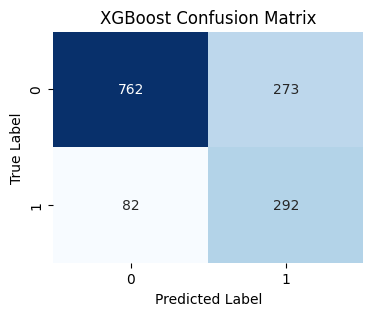


LightGBM Performance Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8383


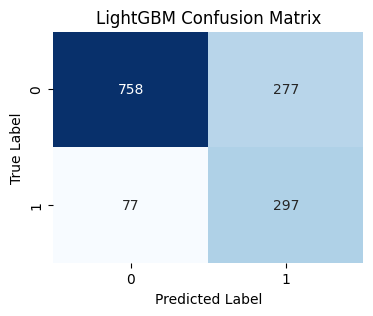

In [16]:
#5. Evaluation
models = {'XGBoost': xgb_model, 'LightGBM': lgb_model}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n{name} Performance Report")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")

    #Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Building your web application using Hugging Face

In [17]:
#Exporting from Google Colab
import joblib
model_artifacts = {
    'scaler': scaler,
    'categorical_cols': list(categorical_cols),
    'numerical_cols': numerical_cols,
    'xgboost_model': xgb_model,
    'lightgbm_model': lgb_model,
    'features_list': list(X.columns)
}

joblib.dump(model_artifacts, 'churn_pipeline_artifacts.joblib')
print("Deployment components successfully exported to 'churn_pipeline_artifacts.joblib'")

Deployment components successfully exported to 'churn_pipeline_artifacts.joblib'


# Insights
By analyzing the internal feature weights of both XGBoost and LightGBM, we can categorize the primary drivers of subscriber attrition into three core buckets:

* The Contract Trap (Highest Predictor): Customers on a Month-to-month contract are exponentially more likely to churn compared to those on One-Year or Two-Year contracts. This is a transactional relationship with zero friction to leave.

* The Technology Friction Gap: Subscribers who have Fiber optic internet but lack complementary sticky add-ons like Online Security, Device Protection, or Tech Support show a massive correlation with churn. This indicates frustration—high-speed tech without a safety net leads to buyers' remorse when technical issues arise.

* The Financial Leverage Threshold: Customers with high Monthly Charges but short Tenure (1 to 5 months) represent the highest financial flight risk. They are highly sensitive to price shocks early in their lifecycle.

#XG Boost vs LightGBM

 **XGBoost (Level-wise)**: Grows trees horizontally, balancing splits level by level.

* Pros: Slower but highly precise; less prone to overfitting on smaller datasets.

* Cons: Computationally expensive on massive datasets.

**LightGBM (Light Gradient Boost - Leaf-wise):** Grows trees vertically, splitting the leaf node that reduces the most overall loss, regardless of symmetry.

* Pros: Blazing fast training speeds; uses up to 80% less memory by grouping similar features together.

* Cons: Can easily overfit on small datasets (requires careful tuning of tree depth).

# Future
* Explainable AI (XAI): Connect SHAP to the web interface so the model doesn't just say who will leave, but gives the exact reason why (e.g., "75% risk due to Fiber Optic without Tech Support").

* Real-Time Streaming: Deploy the pipeline as a live microservice using FastAPI and Docker, hooking it directly into a live CRM (like Salesforce) to trigger automated retention discounts instantly.

* Drift Monitoring: Set up automated checks (using Evidently AI) to monitor if customer behavior changes over time, automatically triggering a model retrain if accuracy drops.